In [1]:
import mudata as md
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, Trace_ELBO, JitTraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.optim import Adam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

smoke_test = True

In [2]:
adata = md.read("/Users/ljb80/Data/PapalexiSatija2021_eccite_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [3]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578


In [4]:
adata.obs = adata.obs.assign(element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True))
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [5]:
control_label = "control"
elements = [e for e in sorted(adata.obs["element"].unique()) if e != control_label]
element_mapping = {element: i + 1 for i, element in enumerate(elements)}
print(element_mapping)
adata.obs["element_id"] = adata.obs["element"].map(element_mapping)
adata.obs["element_id"] = adata.obs["element_id"].fillna(0).astype(int)
adata.obs[["element", "element_id"]]

{'ATF2': 1, 'BRD4': 2, 'CAV1': 3, 'CD86': 4, 'CMTM6': 5, 'CUL3': 6, 'ETV7': 7, 'IFNGR1': 8, 'IFNGR2': 9, 'IRF1': 10, 'IRF7': 11, 'JAK2': 12, 'MARCH8': 13, 'MYC': 14, 'NFKBIA': 15, 'PDCD1LG2': 16, 'POU2F2': 17, 'SMAD4': 18, 'SPI1': 19, 'STAT1': 20, 'STAT2': 21, 'STAT3': 22, 'STAT5A': 23, 'TNFRSF14': 24, 'UBE2L6': 25}


,element,element_id
AAACCTGAGCCAGAAC,STAT2,21
AAACCTGAGTGGACGT,CAV1,3
AAACCTGCATGAGCGA,STAT1,20
AAACCTGTCTTGTCAT,CD86,4
AAACGGGAGAACAACT,IRF7,11
...,...,...
TTTGTCAGTCACTTCC,CMTM6,5
TTTGTCAGTGACGGTA,control,0
TTTGTCAGTTCCACAA,ATF2,1
TTTGTCATCACGCATA,CAV1,3


In [6]:
control_label = "control"
guides = [e for e in sorted(adata.obs["perturbation"].unique()) if e != control_label]
guide_mapping = {guide: i + 1 for i, guide in enumerate(guides)}
print(guide_mapping)
adata.obs["guide_id"] = adata.obs["perturbation"].map(guide_mapping)
adata.obs["guide_id"] = adata.obs["guide_id"].fillna(0).astype(int)
adata.obs[["perturbation", "guide_id"]]

{'ATF2g1': 1, 'ATF2g2': 2, 'ATF2g3': 3, 'ATF2g4': 4, 'BRD4g1': 5, 'BRD4g2': 6, 'BRD4g3': 7, 'BRD4g4': 8, 'CAV1g1': 9, 'CAV1g2': 10, 'CAV1g3': 11, 'CAV1g4': 12, 'CD86g1': 13, 'CD86g2': 14, 'CD86g3': 15, 'CD86g4': 16, 'CMTM6g1': 17, 'CMTM6g2': 18, 'CMTM6g3': 19, 'CUL3g1': 20, 'CUL3g2': 21, 'CUL3g3': 22, 'ETV7g1': 23, 'ETV7g2': 24, 'ETV7g3': 25, 'ETV7g4': 26, 'IFNGR1g1': 27, 'IFNGR1g2': 28, 'IFNGR1g3': 29, 'IFNGR1g4': 30, 'IFNGR2g1': 31, 'IFNGR2g2': 32, 'IFNGR2g3': 33, 'IFNGR2g4': 34, 'IRF1g1': 35, 'IRF1g2': 36, 'IRF1g3': 37, 'IRF1g4': 38, 'IRF7g1': 39, 'IRF7g2': 40, 'IRF7g3': 41, 'IRF7g4': 42, 'JAK2g1': 43, 'JAK2g2': 44, 'JAK2g3': 45, 'JAK2g4': 46, 'MARCH8g1': 47, 'MARCH8g2': 48, 'MARCH8g3': 49, 'MARCH8g4': 50, 'MYCg1': 51, 'MYCg2': 52, 'MYCg3': 53, 'MYCg4': 54, 'NFKBIAg1': 55, 'NFKBIAg2': 56, 'NFKBIAg3': 57, 'NFKBIAg4': 58, 'PDCD1LG2g1': 59, 'PDCD1LG2g2': 60, 'PDCD1LG2g3': 61, 'PDCD1LG2g4': 62, 'POU2F2g1': 63, 'POU2F2g2': 64, 'POU2F2g3': 65, 'POU2F2g4': 66, 'SMAD4g1': 67, 'SMAD4g2': 68,

,perturbation,guide_id
AAACCTGAGCCAGAAC,STAT2g2,80
AAACCTGAGTGGACGT,CAV1g4,12
AAACCTGCATGAGCGA,STAT1g2,76
AAACCTGTCTTGTCAT,CD86g1,13
AAACGGGAGAACAACT,IRF7g2,40
...,...,...
TTTGTCAGTCACTTCC,CMTM6g1,17
TTTGTCAGTGACGGTA,control,0
TTTGTCAGTTCCACAA,ATF2g1,1
TTTGTCATCACGCATA,CAV1g2,10


In [7]:
# pick a subset of random genes including 3 known ones
stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones
stat_target_genes = list(element_mapping.keys())

if smoke_test:
    n_genes_subset = 50
    other_genes = [gene for gene in adata.var_names if gene not in stat_target_genes]
    selected_genes = stat_target_genes + other_genes[: n_genes_subset - len(stat_target_genes)]
    # selected_genes = stat_target_genes + list(
    #     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    # )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    min_counts = 100
    adata_subset = adata[:,adata.X.sum(axis=0) > min_counts]
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 50
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element', 'element_id'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [8]:
control_label = "control"
genes = adata_subset.var_names
gene_mapping = {gene: i + 1 for i, gene in enumerate(genes)}
# list(element_mapping.keys()).map(gene_mapping)

# for element, element_id in element_mapping.items():
# print(element_id, gene_mapping[element] if element in gene_mapping else 0)
target_gene_ids = [
    gene_mapping[element] if element in gene_mapping else 0 for element, element_id in element_mapping.items()
]
target_gene_ids
# adata_subset.obs["target_gene_id"] = adata_subset.obs["target_gene_id"].fillna(0).astype(int)
# adata_subset.obs[["element", "element_id", "target_gene_id"]]

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25]

In [9]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element,element_id
AAACCTGAGCCAGAAC,rep1-tx,80,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2,21
AAACCTGAGTGGACGT,rep1-tx,12,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1,3
AAACCTGCATGAGCGA,rep1-tx,76,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1,20
AAACCTGTCTTGTCAT,rep1-tx,13,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86,4
AAACGGGAGAACAACT,rep1-tx,40,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,17,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6,5
TTTGTCAGTGACGGTA,rep4-tx,0,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control,0
TTTGTCAGTTCCACAA,rep3-tx,1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2,1
TTTGTCATCACGCATA,rep3-tx,10,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1,3


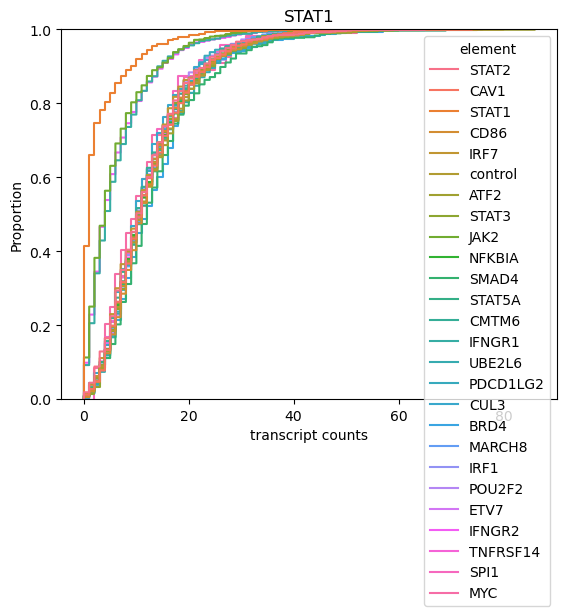

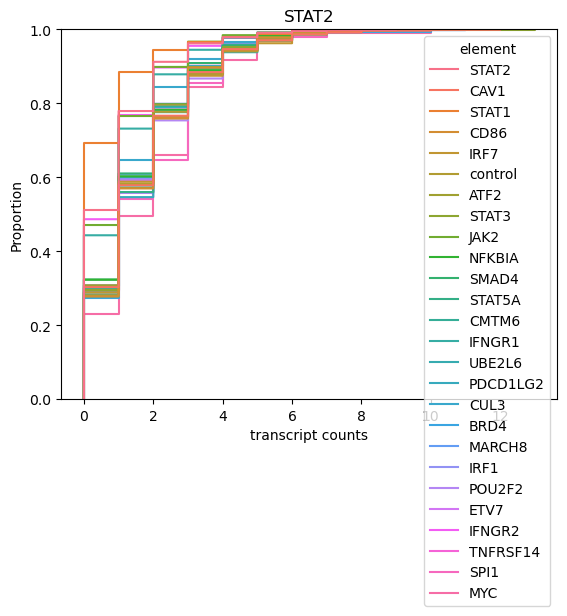

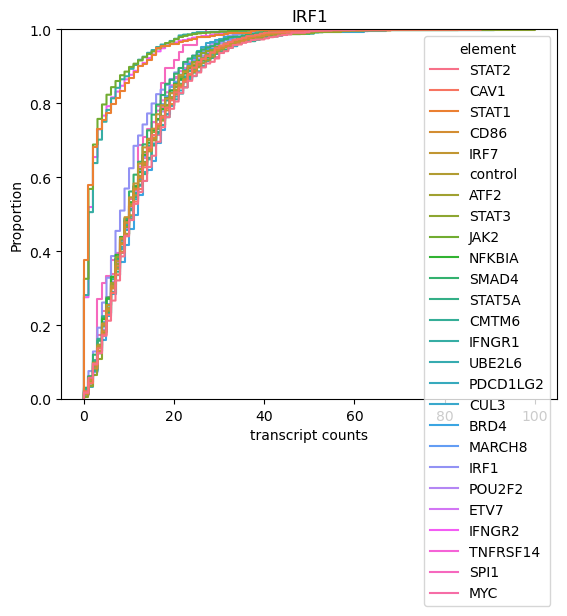

In [10]:
import seaborn as sns

# sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# counts = adata_subset[:, "IRF1"].X.todense().A1
# guide_ids = ["control"] + [f"STAT1g{i}" for i in range(1,5)]
# for guide_id in guide_ids:
# perts = adata.obs["guide_id"].str.contains(f"STAT1g{i}").values
for gene in ["STAT1", "STAT2", "IRF1"]:
    counts = adata_subset[:, gene].X.todense().A1
    sns.ecdfplot(x=counts, hue=adata_subset.obs["element"])
    plt.title(gene)
    plt.xlabel("transcript counts")
    plt.show()

In [11]:
covariate_cols = ["ncounts"]
adata_subset.X.sum(axis=0).A1

array([7.50900e+03, 3.23970e+04, 5.28000e+02, 5.06800e+03, 5.24190e+04,
       9.16000e+03, 5.60790e+04, 2.11900e+04, 1.15323e+05, 2.18361e+05,
       1.10917e+05, 4.80860e+04, 7.09000e+02, 1.54620e+04, 7.35920e+04,
       4.67000e+03, 1.10840e+04, 4.56500e+03, 1.98647e+05, 2.33330e+05,
       2.91440e+04, 4.39350e+04, 3.01400e+03, 3.19850e+04, 1.48627e+05,
       2.44000e+02, 1.25200e+03, 9.00000e+01, 2.54000e+02, 5.49000e+02,
       1.98700e+03, 3.36000e+02, 3.98000e+02, 2.97000e+02, 8.87400e+03,
       4.76000e+02, 6.74000e+02, 3.92000e+02, 1.12594e+05, 2.90200e+03,
       2.20000e+02, 1.52700e+03, 1.23000e+02, 1.37200e+03, 7.30530e+04,
       5.08100e+03, 7.42000e+02, 6.00000e+00, 2.02970e+04, 3.60000e+01],
      dtype=float32)

In [12]:
# read the data to tensors
counts = torch.tensor(adata_subset.X.todense(), dtype=torch.int32)
# counts = torch.tensor(adata_subset.X.todense(), dtype=torch.int32).to_sparse()
# counts = torch.sparse_csr_tensor(adata_subset.X, dtype=torch.int32)

# perturbations = torch.tensor(
#     adata_subset.obs["perturbation"].str.replace("STAT1g", "").str.replace("control", "0").values.astype(int),
#     dtype=torch.long,
# )
guide_ids = torch.tensor(adata_subset.obs["guide_id"].values, dtype=torch.long)
element_ids = torch.tensor(adata_subset.obs["element_id"].values, dtype=torch.long)
target_ids = torch.tensor(target_gene_ids, dtype=torch.long)
target_ids_matrix = torch.nn.functional.one_hot(target_ids, num_classes=counts.shape[1]+1)[:,1:]
print(target_ids_matrix)

lib_size = torch.tensor(adata_subset.obs["ncounts"].values)
size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)
gene_mean = torch.tensor(adata_subset.X.mean(axis=0).A1)
# covariates = torch.tensor(adata_subset.obs[covariate_cols].values)
# covariates = torch.hstack(torch.ones((n_cells,)), covariates)

# get data shapes
n_guides = int(guide_ids.max())
n_elements = int(element_ids.max())
n_cells, n_genes = counts.shape
# n_covariates = len(covariate_cols) + 1

print(n_guides, n_elements, n_cells, n_genes)

# print(lib_size.unsqueeze(dim=-1).log())

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [0, 1, 0,  ..., 0, 0, 0],
        [0, 0, 1,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
98 25 20729 50


/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_98914/780054640.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)


(array([ 570., 1458., 2670., 4007., 4830., 4042., 2245.,  763.,  133.,
          11.]),
 array([-1.36212385, -1.04376841, -0.72541302, -0.40705764, -0.08870222,
         0.22965318,  0.54800856,  0.866364  ,  1.18471944,  1.50307477,
         1.82143021]),
 <BarContainer object of 10 artists>)

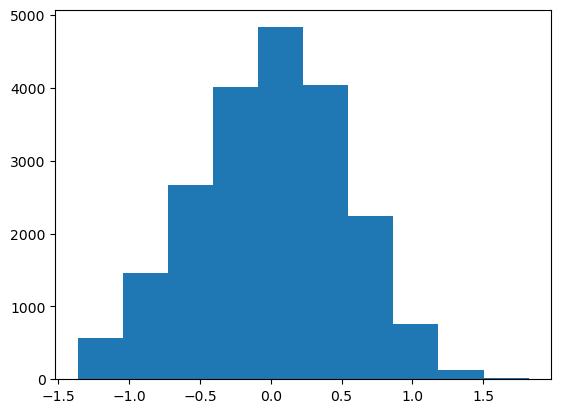

In [13]:
plt.hist(size_factor.squeeze())

/Users/ljb80/mambaforge/envs/pyro/lib/python3.10/site-packages/torch/distributions/distribution.py:167: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


tensor(0.0598)

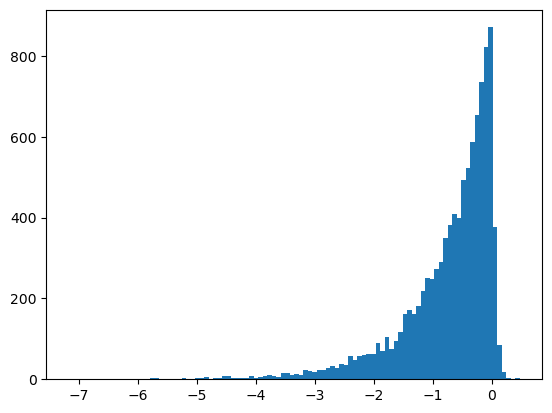

In [14]:
asym_laplace_samples = dist.AsymmetricLaplace(0.0, 0.2, 4).sample_n(10000)
plt.hist(asym_laplace_samples, bins=100)
(asym_laplace_samples>0).float().mean()

In [15]:
dist.Exponential(0.05).sample_n(10)

tensor([19.7382,  9.2183, 16.9824,  9.6926,  5.2411, 17.8420,  1.6489, 32.3037,
        23.7442, 16.0659])

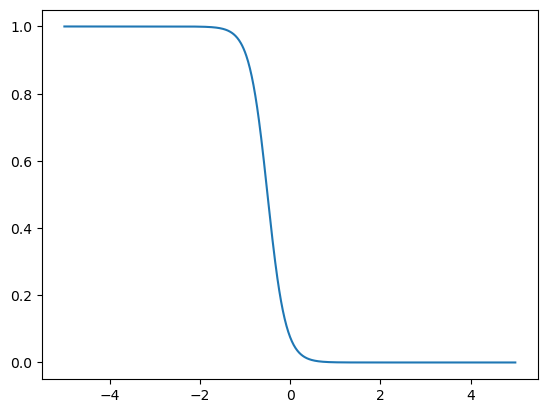

In [16]:
x_0 = -0.5
scale=5
x = torch.arange(-5, 5, 0.01)
y = torch.sigmoid(scale*(x_0-x))
plt.plot(x,y)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          1.,   0.,   0.,   3.,   0.,   3.,   1.,   2.,   7.,   4.,   1.,
          6.,   5.,   4.,  10.,  16.,  22.,  12.,  18.,  18.,  28.,  32.,
         56.,  58.,  60.,  80.,  94., 104., 141., 184., 218., 261., 280.,
        350., 418., 507., 700., 775., 927., 841., 688., 539., 442., 365.,
        325., 244., 188., 185., 127., 109., 111.,  70.,  73.,  55.,  40.,
         30.,  31.,  21.,  15.,  14.,  13.,  13.,  10.,  16.,   4.,   6.,
          3.,   2.,   2.,   0.,   0.,   3.,   0.,   1.,   2.,   0.,   2.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-0.94998449, -0.93082827, -0.911672  , -0.89251578, -0.87335956,
        -0.85420334, -0.83504713, -0.81589085, -0.79673463, -0.77757841,
        -0.75842214, -0.73926592, -0.7201097 , -0.70095348, -0.68179727,
        -0.66264099, -0.64348477, -0.62432855, -0.60517228, -0.58601606,
        -0.56685984, -0.54

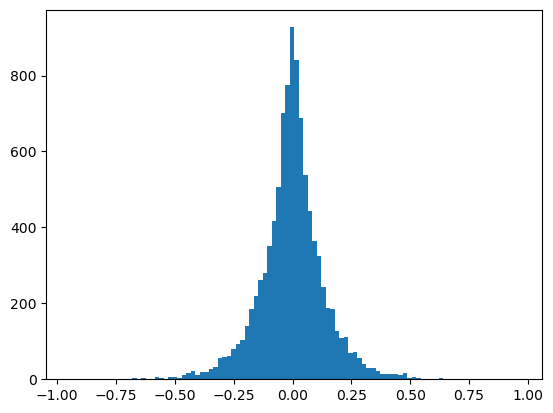

In [17]:
laplace_samples = dist.Laplace(0.0, 0.1).sample_n(10000)
plt.hist(laplace_samples, bins=100)


In [18]:
# @config_enumerate
# def model(
#     counts,
#     guide_ids,
#     element_ids,
#     target_ids,
#     n_factors=None,  # number of latent factors/confounders
#     size_factor=0,  # size factor = log(lib_size) - mean(log(lib_size))
#     n_genes=1,
#     subsample_size=None,
# ):
#     n_guides = int(guide_ids.max())
#     n_elements = int(element_ids.max())
#     if counts is not None:
#         n_cells, n_genes = counts.shape
#     else:
#         assert guide_ids.shape == element_ids.shape
#         (n_cells,) = element_ids.shape
#     assert target_ids.shape == (n_elements, n_genes)
#     guides_plate = pyro.plate("guides", n_guides, dim=-2)
#     elements_plate = pyro.plate("elements", n_elements, dim=-2)
#     cells_plate = pyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
#     genes_plate = pyro.plate("genes", n_genes, dim=-1)
#     pcs_plate = pyro.plate("factors", n_factors, dim=-3)
#     assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))

#     if n_factors is not None:
#         with cells_plate, pcs_plate:
#             pcs = pyro.sample("ppc_factors", dist.Normal(0, 1)).squeeze(dim=-1).transpose(-1, -2)  # cells x factors
#         with genes_plate, pcs_plate:
#             loadings = pyro.sample("ppc_loadings", dist.Normal(0, 1)).squeeze(-2)  # factors x genes

#     with guides_plate:
#         efficiency = pyro.sample("efficiency", dist.Beta(10.0, 1.0))
#     efficiency = torch.vstack((torch.tensor(0), efficiency))  # add dummy value for NTC guides
#     # efficiency = torch.full((n_guides + 1,), efficiency)
#     with cells_plate as idx:
#         guide_ids = guide_ids[idx]
#         affected = pyro.sample("affected", dist.Bernoulli(probs=efficiency[guide_ids], validate_args=True))

#         # with guides_plate:
#         # with elements_plate:

#         # effect = pyro.sample("effect", dist.Normal(0.0, 3.0))

#     with elements_plate:
#         cis_effect = pyro.sample("cis_effect", dist.AsymmetricLaplace(0.0, 0.2, 4))

#     with genes_plate:
#         mean = pyro.sample("mean", dist.LogNormal(0.0, 10.0))
#         dispersion = pyro.sample("dispersion", dist.LogNormal(3.0, 5.0))

#         # print(ontarget_beta.shape)
#         # ontarget_effect_element =

#         # with guides_plate:
#         with elements_plate:
#             # is_target = pyro.sample("is_target", dist.Bernoulli(probs=0.01, validate_args=True))
#             # trans_effect = pyro.sample("trans_effect", dist.Normal(0.0, 0.1)) * torch.exp(3.0 * is_target)
#             trans_effect = pyro.sample("trans_effect", dist.Cauchy(0.0, 0.1))
#             # effect = pyro.sample("effect", dist.Normal(0.0, 3.0))
#         total_effect_padded = torch.vstack(
#             (torch.zeros(1, n_genes), cis_effect * target_ids + trans_effect * (1 - target_ids))
#         )
#         # beta = torch.vstack((torch.zeros(1, n_genes), total_effect))  # add dummy column for "control" element
#         # cis_effect = Vindex(ontarget_beta[:, None])[target_ids_padded]
#         # print(cis_effect.shape, cis_effect, beta.shape)

#         with cells_plate as idx:
#             element_ids = element_ids[idx]
#             if counts is not None and subsample_size is not None:
#                 counts = counts[idx, :]
#             size_factor = size_factor[idx, :]
#             logits = (
#                 # cis_effect_padded[element_ids, :] * affected  # mixture model only for cis effect
#                 # + trans_effect_padded[element_ids, :] * affected
#                 total_effect_padded[element_ids, :] * affected + mean.log() + size_factor
#             )
#             if n_factors is not None:
#                 logits += pcs @ loadings
#             # obs = pyro.sample("counts", dist.Poisson(logits.exp() + epsilon), obs=counts)
#             obs = pyro.sample(
#                 "counts",
#                 dist.NegativeBinomial(total_count=dispersion, logits=logits - dispersion.log()),
#                 obs=counts,
#             )
#     return obs


# args = (counts, guide_ids, element_ids, target_ids_matrix)
# kwargs = {
#     "size_factor": size_factor,
#     # "subsample_size": 1024,
#     "n_factors": 5,
#     "n_genes": n_genes,
# }
# render_model(model, model_args=args, model_kwargs=kwargs, render_distributions=True)
# # render_model(model, model_args=(None, perturbations), model_kwargs=kwargs)

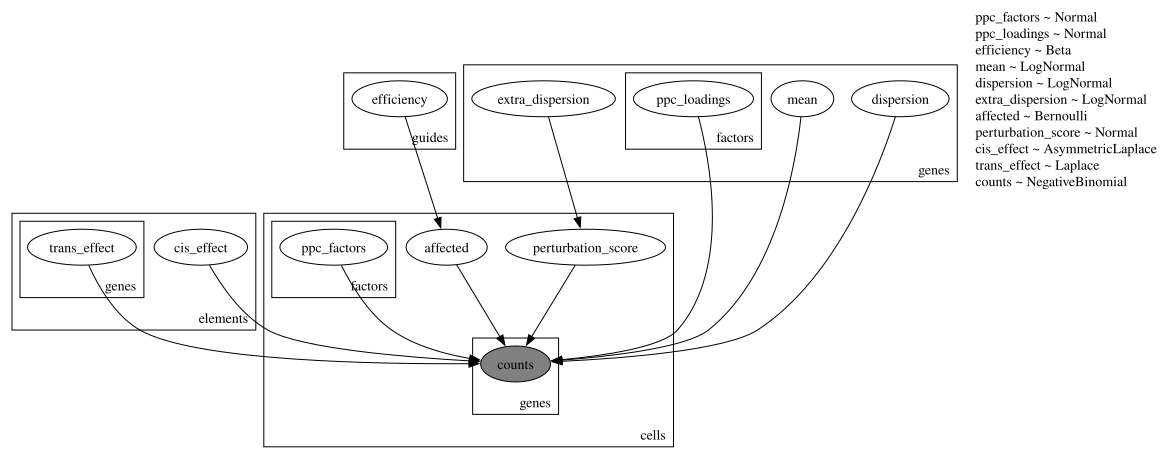

In [19]:
relu = torch.nn.ReLU()
# relu = torch.nn.LeakyReLU()
# relu = lambda x: x


@config_enumerate
def model_fancy(
    counts,
    guide_ids,
    element_ids,
    target_ids,
    n_factors=None,  # number of latent factors/confounders
    size_factor=0,  # size factor = log(lib_size) - mean(log(lib_size))
    n_genes=1,
    subsample_size=None,
    use_perturbation_mixture=True,
    use_perturbation_score=False,
    n_guides=None,
    n_elements=None,
    epsilon=1e-6,
):
    if n_guides is None:
        n_guides = int(guide_ids.max())
    if n_elements is None:
        n_elements = int(element_ids.max())
    if counts is not None:
        n_cells, n_genes = counts.shape
    else:
        assert guide_ids.shape == element_ids.shape
        (n_cells,) = element_ids.shape
    assert target_ids.shape == (n_elements, n_genes)
    guides_plate = pyro.plate("guides", n_guides, dim=-2)
    elements_plate = pyro.plate("elements", n_elements, dim=-2)
    cells_plate = pyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
    genes_plate = pyro.plate("genes", n_genes, dim=-1)
    pcs_plate = pyro.plate("factors", n_factors, dim=-3)
    assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))

    if n_factors is not None:
        with cells_plate, pcs_plate:
            pcs = pyro.sample("ppc_factors", dist.Normal(0, 1)).squeeze(dim=-1).transpose(-1, -2)  # cells x factors
        with genes_plate, pcs_plate:
            loadings = pyro.sample("ppc_loadings", dist.Normal(0, 1)).squeeze(-2)  # factors x genes

    with guides_plate:
        # efficiency_alpha = pyro.param("efficiency_alpha", torch.tensor((10.0,)), constraint=dist.constraints.positive)
        # efficiency_beta = pyro.param("efficiency_beta", torch.tensor((1.0,)), constraint=dist.constraints.positive)
        efficiency = pyro.sample("efficiency", dist.Beta(10.0, 1.0))
    efficiency = torch.vstack((torch.tensor(0), efficiency))  # add dummy value for NTC guides

    with genes_plate:
        mean = pyro.sample("mean", dist.LogNormal(0.0, 10.0))
        dispersion = pyro.sample("dispersion", dist.LogNormal(3.0, 5.0))
        pert_dispersion = pyro.sample("extra_dispersion", dist.LogNormal(-1.0, 3.0))

    with cells_plate as idx:
        guide_ids = guide_ids[idx]
        element_ids = element_ids[idx]
        if counts is not None and subsample_size is not None:
            counts = counts[idx, :]
        size_factor = size_factor[idx, :]

        affected = pyro.sample("affected", dist.Bernoulli(probs=efficiency[guide_ids]))
        perturbation_offset = pyro.sample("perturbation_score", dist.Normal(0.0, pert_dispersion[element_ids, None]))

    with elements_plate:
        cis_effect = pyro.sample("cis_effect", dist.AsymmetricLaplace(0.0, 0.2, 4))
        cis_effect_padded = torch.vstack((torch.zeros((1,)), cis_effect))

    with genes_plate:
        with elements_plate:
            trans_effect = pyro.sample("trans_effect", dist.Laplace(0.0, 0.1))
            trans_effect_padded = torch.vstack((torch.zeros(1, n_genes), trans_effect * (1 - target_ids)))
            # k = pyro.sample("trans_effect_k", dist.Exponential(0.1))
            # k_padded = torch.vstack((torch.zeros(1, n_genes), k))
            # offset = pyro.sample("trans_effect_offset", dist.Normal(-1, 1))
            # offset_padded = torch.vstack((torch.zeros(1, n_genes), offset))

        with cells_plate:
            # what is the magnitude of the cis effect in each cell?
            perturbation_score = cis_effect_padded[element_ids, :] + perturbation_offset

            # what is the cell x gene version of the cis effect in each cell?
            target_ids_padded = torch.vstack((torch.zeros(1, n_genes), target_ids))
            cis_effect_cell = target_ids_padded[element_ids, :] * perturbation_score

            # what is the expected trans effect for each cell given the guides in that cell?
            trans_effect_cell = trans_effect_padded[element_ids, :]

            # what is the cell x gene trans effect in each cell after accounting for perturbation score?
            if use_perturbation_score:
                # trans_effect_cell_scaled = trans_effect_cell * relu(-perturbation_score)
                trans_effect_cell_scaled = trans_effect_cell * relu(-perturbation_score)
            else:
                trans_effect_cell_scaled = trans_effect_cell

            # what is the total combined perturbation effect in each cell across all genes?
            if use_perturbation_mixture:
                total_effect_cell = (trans_effect_cell_scaled + cis_effect_cell) * affected
            else:
                total_effect_cell = trans_effect_cell_scaled + cis_effect_cell

            # what is the predicted gene expression as a function of perturbations and covariates?
            logits = mean.log() + size_factor + total_effect_cell

            # add latent confounder effects if needed
            if n_factors is not None:
                logits += pcs @ loadings

            obs = pyro.sample(
                "counts", dist.NegativeBinomial(total_count=dispersion, logits=logits - dispersion.log()), obs=counts
            )
            # obs = pyro.sample("counts", dist.Poisson(logits.exp()), obs=counts)

    return obs


args = (counts, guide_ids, element_ids, target_ids_matrix)
kwargs = {
    "size_factor": size_factor,
    # "subsample_size": 4096,
    "n_factors": 10,
    # "n_guides": int(guide_ids.max()),
    # "n_elements": int(element_ids.max()),
    "n_genes": n_genes,
}
model = model_fancy

render_model(model_fancy, model_args=args, model_kwargs=kwargs, render_distributions=True, render_params=True)
# render_model(model, model_args=(None, perturbations), model_kwargs=kwargs)

In [20]:
args = (counts, guide_ids, element_ids, target_ids_matrix)
control_cells = guide_ids == 0
args_pretrain = (counts[control_cells, ...], guide_ids[control_cells], element_ids[control_cells], target_ids_matrix)
[v.shape for v in args_pretrain]

kwargs_pretrain = {
    "size_factor": size_factor[control_cells,:],
    "n_factors": kwargs["n_factors"],
    "n_guides": int(guide_ids.max()),
    "n_elements": int(element_ids.max()),
    "n_genes": n_genes,
}

# [v.shape for v in args]
size_factor.shape

torch.Size([20729, 1])

100%|██████████| 500/500 [00:10<00:00, 46.40it/s]


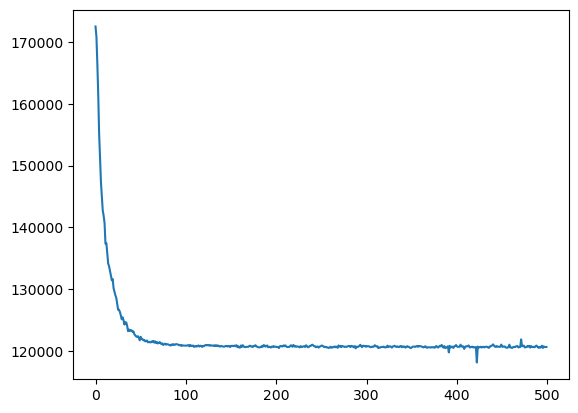

In [21]:
from pyro import subsample
from pyro.optim import ClippedAdam

pyro.clear_param_store()
# optimizer = Adam("lr":0.01")
simple_model = poutine.condition(model, data={"affected": torch.zeros_like(args_pretrain[0]).float()})
simple_guide = AutoNormal(
    simple_model, init_loc_fn=init_to_value(values={"mean": gene_mean}, fallback=init_to_median(num_samples=100))
)
simple_svi = SVI(simple_model, simple_guide, ClippedAdam({"lr": 0.1}), loss=Trace_ELBO())

losses=[]
for _ in tqdm(range(500)):
    loss = simple_svi.step(*args_pretrain, **kwargs_pretrain)
    losses.append(loss)
plt.plot(losses)

In [47]:
init_values = simple_guide.median()
init_values.pop("ppc_factors")
init_values.pop("perturbation_score")
guide = AutoNormal(
    poutine.block(model, hide=["affected", "counts", "is_target"]),
    init_loc_fn=init_to_value(values=init_values, fallback=init_to_median(num_samples=100)),
)
elbo = TraceEnum_ELBO(max_plate_nesting=3)
# elbo = JitTraceEnum_ELBO(max_plate_nesting=3)
# optimizer = Adam({"lr": 0.1})
pyro.clear_param_store()

# args = (None, perturbations)
for a in args:
    if a is not None:
        print(a.shape, a.dtype)

epochs = 200
if "subsample_size" in kwargs:
    steps = epochs * int(adata_subset.n_obs / kwargs["subsample_size"])
    optimizer = ClippedAdam({"lr": 0.1, "lrd": 1 - (5 / steps)})
else:
    steps = epochs
    optimizer = ClippedAdam({"lr": 0.1, "lrd": 0.99})
lr_decay = 1 - (5 / epochs)

svi = SVI(model, guide, optimizer, loss=elbo)
losses = []

for _ in tqdm(range(steps)):
    loss = svi.step(*args, **kwargs)
    losses.append(loss)
plt.plot(losses)

torch.Size([20729, 50]) torch.int32
torch.Size([20729]) torch.int64
torch.Size([20729]) torch.int64
torch.Size([25, 50]) torch.int64


 18%|█▊        | 36/200 [00:05<00:20,  7.92it/s]

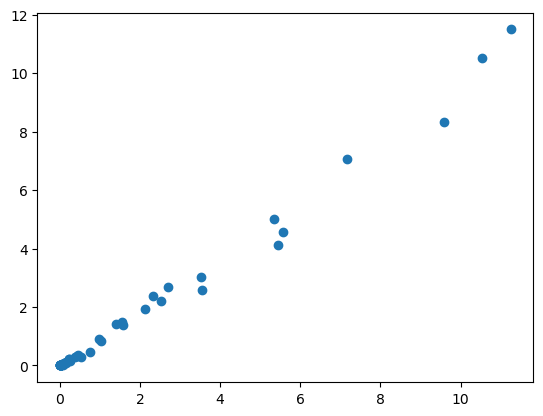

In [23]:
plt.scatter(adata_subset.X.mean(axis=0).A1, simple_guide.median()["mean"])

[]

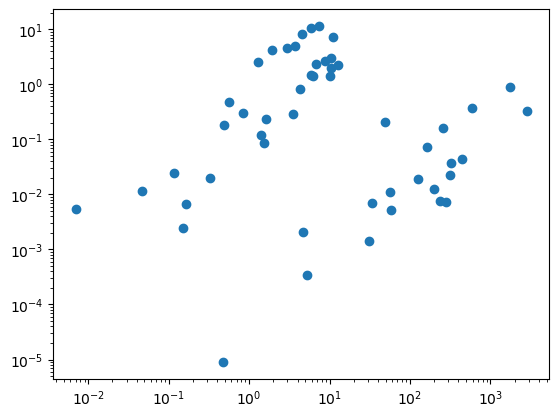

In [24]:
plt.scatter(simple_guide.median()["dispersion"], simple_guide.median()["mean"])
plt.loglog()

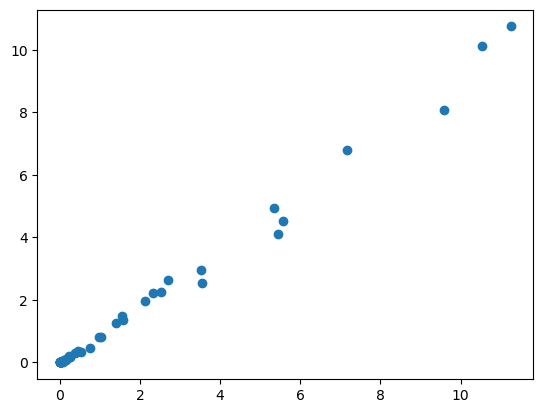

In [25]:
# sanity check: make sure gene means roughly agree with observed mean
plt.scatter(adata_subset.X.mean(axis=0).A1, guide.median()["mean"])

array([[<Axes: title={'center': 'efficiency'}>]], dtype=object)

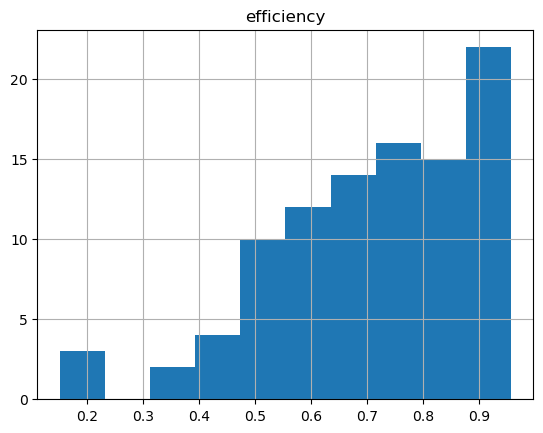

In [26]:
median_efficiency = pd.DataFrame(
    guide.median()["efficiency"], index=list(guide_mapping.keys())[:n_guides], columns=["efficiency"]
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'ATF2'),
  Text(1, 0, 'BRD4'),
  Text(2, 0, 'CAV1'),
  Text(3, 0, 'CD86'),
  Text(4, 0, 'CMTM6'),
  Text(5, 0, 'CUL3'),
  Text(6, 0, 'ETV7'),
  Text(7, 0, 'IFNGR1'),
  Text(8, 0, 'IFNGR2'),
  Text(9, 0, 'IRF1'),
  Text(10, 0, 'IRF7'),
  Text(11, 0, 'JAK2'),
  Text(12, 0, 'MARCH8'),
  Text(13, 0, 'MYC'),
  Text(14, 0, 'NFKBIA'),
  Text(15, 0, 'PDCD1LG2'),
  Text(16, 0, 'POU2F2'),
  Text(17, 0, 'SMAD4'),
  Text(18, 0, 'SPI1'),
  Text(19, 0, 'STAT1'),
  Text(20, 0, 'STAT2'),
  Text(21, 0, 'STAT3'),
  Text(22, 0, 'STAT5A'),
  Text(23, 0, 'TNFRSF14'),
  Text(24, 0, 'UBE2L6')])

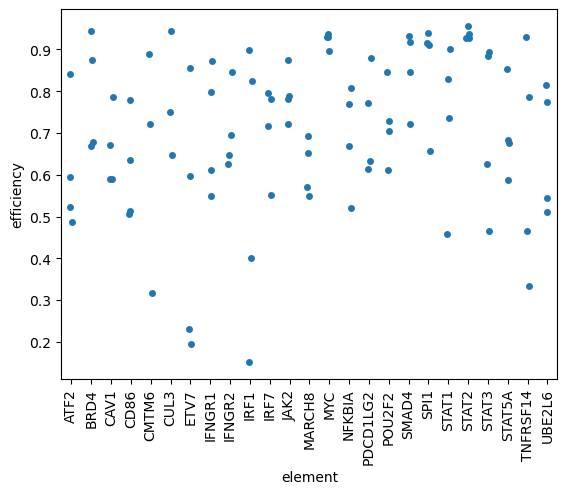

In [27]:
sns.stripplot(median_efficiency, x="element", y="efficiency")
plt.xticks(rotation=90)

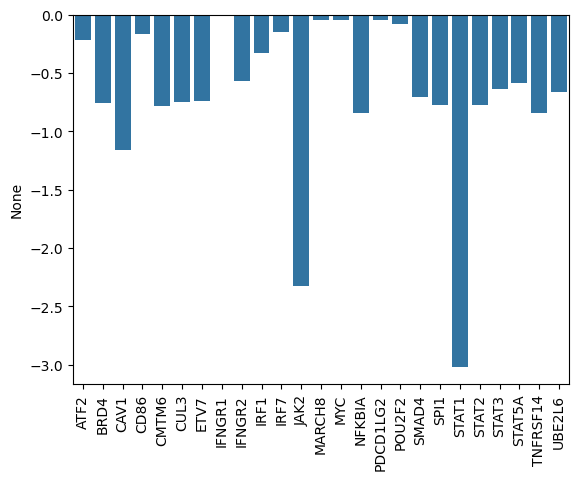

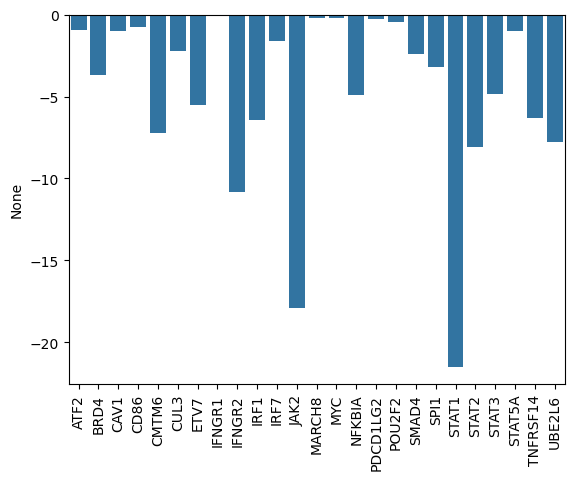

In [28]:
median_cis_effect = guide.median()["cis_effect"]
low_cis_effect, high_cis_effect = guide.quantiles([0.159, 0.841])["cis_effect"]
sigma_cis_effect = high_cis_effect - low_cis_effect
z_score_cis_effect = median_cis_effect / sigma_cis_effect

sns.barplot(x=element_mapping.keys(), y=median_cis_effect.squeeze())
plt.xticks(rotation=90)
plt.show()

sns.barplot(x=element_mapping.keys(), y=z_score_cis_effect.squeeze())

plt.xticks(rotation=90)
plt.show()

In [29]:
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

median_effect = guide.median()["trans_effect"]
low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"]
sigma_effect = high_effect - low_effect
z_score_effect = median_effect / sigma_effect

effects_df = pd.DataFrame(
    z_score_effect,
    columns=adata_subset.var_names,
    index=list(element_mapping.keys())[:n_elements],
)
effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df

gene_symbol,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,RP11-54O7.18,C1orf159,TNFRSF18,TNFRSF4,SDF4,B3GALT6,FAM132A,RP5-902P8.12,UBE2J2,SCNN1D
ATF2,0.073252,0.017640,0.244237,0.239512,0.318769,0.504659,0.809698,0.028284,-0.580872,0.126864,...,0.043681,0.272655,0.129842,-0.322950,-0.040316,-0.053772,0.221844,-0.011026,-0.170498,-0.144701
BRD4,-0.141925,0.229261,-0.073403,-0.846871,-0.666202,-0.066970,1.618401,-1.858968,0.584319,1.674441,...,-0.019391,-0.097626,-0.162574,0.001041,0.215612,-0.112405,-0.163468,-0.167251,-1.005636,0.050125
CAV1,-0.064630,-0.243703,-0.199536,-0.319169,-0.062440,-1.154589,0.092290,0.065969,0.044443,1.418957,...,-0.065410,-0.478924,-0.244113,-0.330307,0.569216,0.069584,0.116594,-0.171307,-0.494732,0.271474
CD86,0.185855,0.017029,0.082622,0.123174,0.869885,-0.218282,-0.665119,0.110080,-0.339833,0.608631,...,-0.099784,-0.113599,-0.019527,-0.085774,0.347521,-0.199390,-0.196917,-0.019849,-0.149524,-0.144706
CMTM6,0.376742,0.145378,0.264497,0.040706,0.051656,-0.091640,-0.324503,-0.578790,0.579340,-0.302024,...,0.264457,0.306238,-0.155077,-0.167010,-0.618723,0.096837,0.093751,-0.003187,-0.651592,-0.204867
CUL3,-0.033306,-0.000443,1.625111,-0.042938,-0.192856,-0.110124,0.496053,1.717779,-0.964919,0.626365,...,0.106248,0.031908,-0.047112,0.186093,-1.445018,-0.245045,0.027722,-0.025415,-0.130014,-0.090358
ETV7,-0.024308,0.085966,0.152231,0.014288,0.150977,0.061469,0.203717,0.185839,0.083939,1.262769,...,0.000098,0.034164,-0.273597,-0.067997,0.064091,0.274486,0.198343,-0.223830,0.566464,-0.059527
IFNGR1,1.089710,0.251677,-0.484424,-1.191019,-2.010066,2.147300,-15.366453,0.091750,6.742078,-35.663025,...,-0.037686,-0.265088,-0.011254,0.044734,1.977266,1.906117,1.040766,0.160148,1.863694,0.036314
IFNGR2,0.820540,1.276270,0.002984,-2.098208,-1.445658,2.140325,-15.706678,5.409635,-0.241050,-27.083338,...,0.053215,-0.788482,0.039965,0.347671,2.635798,2.182941,-0.035858,0.036837,2.248041,0.274706
IRF1,0.139700,1.110278,-0.369124,3.550177,0.667959,0.219619,-9.841153,0.566683,-0.869494,-0.047166,...,-0.222651,-0.502754,0.178002,0.921965,0.842970,0.333623,-0.058199,0.120654,-0.157957,-0.004468


In [30]:
plot_genes = list(effects_df.index)
plot_genes

['ATF2',
 'BRD4',
 'CAV1',
 'CD86',
 'CMTM6',
 'CUL3',
 'ETV7',
 'IFNGR1',
 'IFNGR2',
 'IRF1',
 'IRF7',
 'JAK2',
 'MARCH8',
 'MYC',
 'NFKBIA',
 'PDCD1LG2',
 'POU2F2',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT2',
 'STAT3',
 'STAT5A',
 'TNFRSF14',
 'UBE2L6']

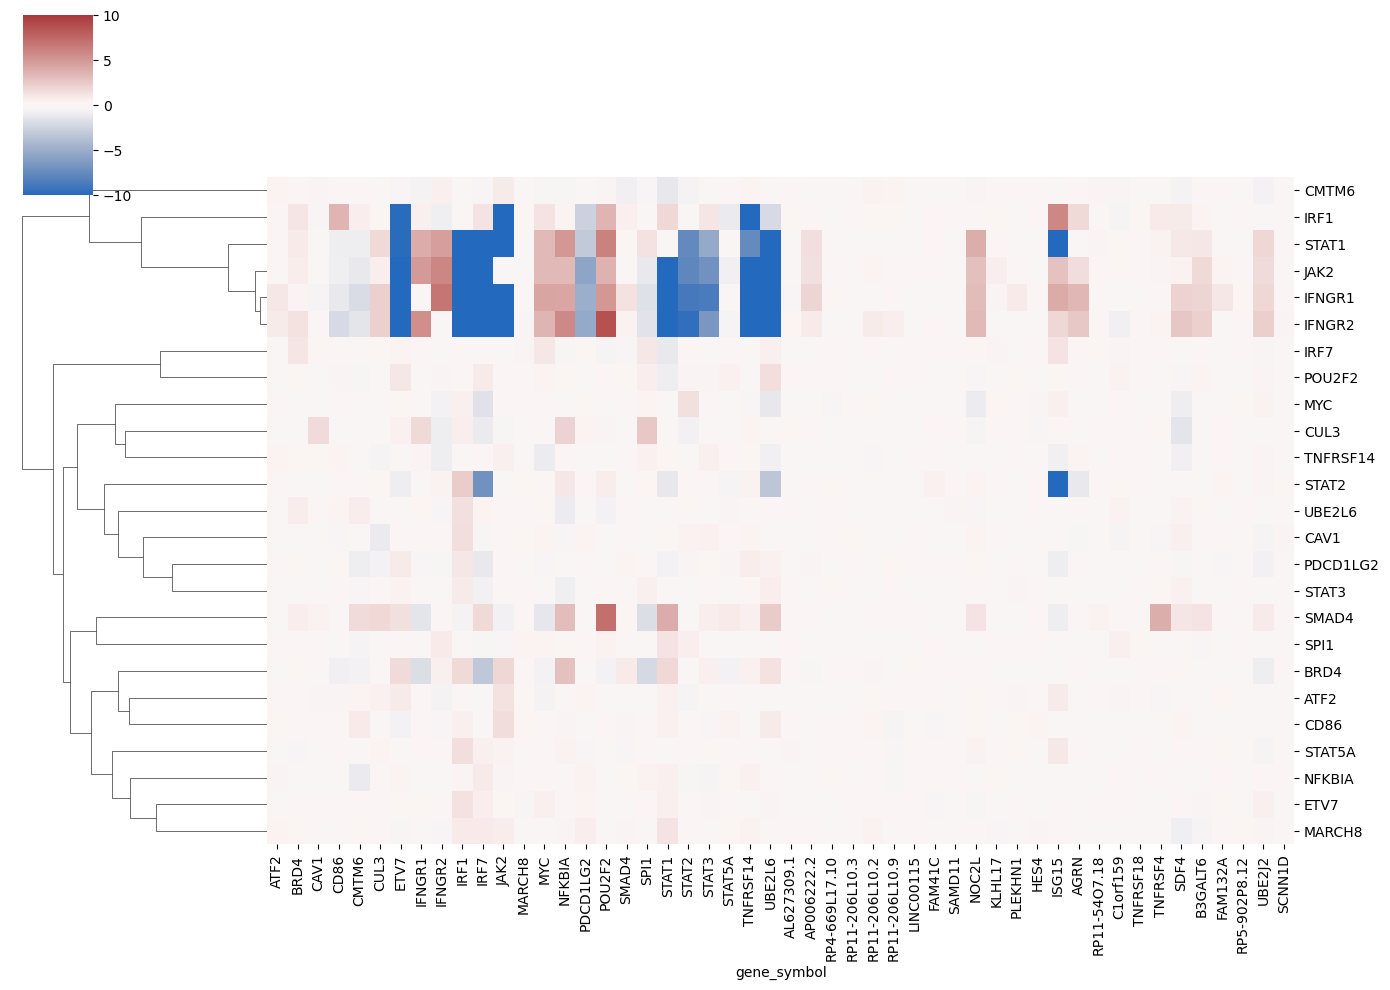

In [31]:
sns.clustermap(effects_df, vmax=10, vmin=-10, cmap="vlag", metric="cosine", figsize=(14,10), col_cluster=False)

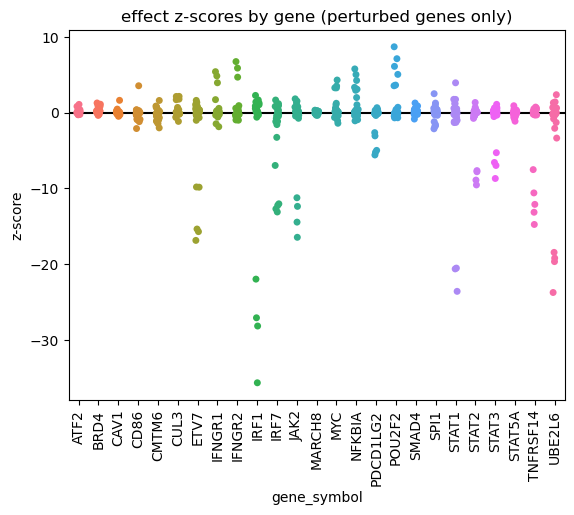

In [32]:
n_plot_genes=25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
# 
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("z-score")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

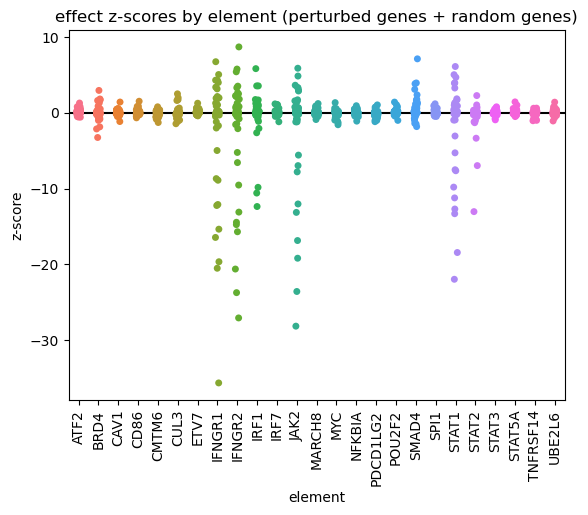

In [33]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("z-score")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

In [34]:
effects_df.T["CUL3"].sort_values()

gene_symbol
SDF4            -1.445018
IRF7            -1.151788
IFNGR2          -0.964919
STAT2           -0.756762
NOC2L           -0.498026
JAK2            -0.448370
HES4            -0.326884
STAT1           -0.296147
LINC00115       -0.293377
STAT3           -0.278318
B3GALT6         -0.245045
UBE2L6          -0.219853
RP11-206L10.2   -0.194459
CMTM6           -0.192856
RP11-206L10.9   -0.188108
AGRN            -0.166456
RP4-669L17.10   -0.151729
SMAD4           -0.139821
UBE2J2          -0.130014
CUL3            -0.110124
STAT5A          -0.105340
RP11-206L10.3   -0.091390
SCNN1D          -0.090358
TNFRSF18        -0.047112
CD86            -0.042938
ATF2            -0.033306
MARCH8          -0.033076
RP5-902P8.12    -0.025415
BRD4            -0.000443
FAM132A          0.027722
C1orf159         0.031908
MYC              0.034148
ISG15            0.047029
KLHL17           0.052657
PLEKHN1          0.063402
FAM41C           0.066875
AP006222.2       0.089983
SAMD11           0.104598


In [35]:
alpha = 0.001
level = alpha / (n_genes * n_elements)
low, high = guide.quantiles([level, 1 - level])["trans_effect"]
(low < 0) & (high > 0)

tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]])

In [36]:
guide.median()

{'ppc_factors': tensor([[[-0.2115],
          [-0.2534],
          [-0.7230],
          ...,
          [ 0.4763],
          [-0.9773],
          [ 0.8340]],
 
         [[-0.1502],
          [-0.5310],
          [ 0.0290],
          ...,
          [ 0.2728],
          [-0.0711],
          [-1.1433]],
 
         [[ 0.2055],
          [-0.1036],
          [ 0.1542],
          ...,
          [-0.1092],
          [ 0.5897],
          [ 0.1645]],
 
         ...,
 
         [[ 0.0628],
          [-0.3798],
          [ 0.9071],
          ...,
          [-0.3228],
          [-0.0164],
          [ 0.0031]],
 
         [[-0.6508],
          [ 0.1385],
          [-0.0819],
          ...,
          [-0.1040],
          [ 1.0756],
          [ 0.6352]],
 
         [[ 0.3414],
          [-0.2509],
          [-0.1940],
          ...,
          [ 0.1910],
          [-0.4703],
          [ 0.2000]]]),
 'ppc_loadings': tensor([[[ 2.7025e-01,  7.7386e-02, -2.9402e-01, -1.7493e-01, -2.6711e-02,
           -7

In [37]:
# if "subsample_size" in kwargs:
#     kwargs.pop("subsample_size")
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals

args_sim = (None, *args[1:])
counts_simulated = trained_model(*args_sim, **kwargs)


# def classifier(args, temperature=0):
#     inferred_model = infer_discrete(
#         trained_model, temperature=temperature, first_available_dim=-3
#     )  # avoid conflict with data plate
#     trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
#     return trace.nodes["has_guide"]["value"]

adata_subset.obs["perturbation"]
# print(classifier(args))

AAACCTGAGCCAGAAC    STAT2g2
AAACCTGAGTGGACGT     CAV1g4
AAACCTGCATGAGCGA    STAT1g2
AAACCTGTCTTGTCAT     CD86g1
AAACGGGAGAACAACT     IRF7g2
                     ...   
TTTGTCAGTCACTTCC    CMTM6g1
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA     ATF2g1
TTTGTCATCACGCATA     CAV1g2
TTTGTCATCTGTACGA    STAT3g1
Name: perturbation, Length: 20729, dtype: category
Categories (99, object): ['ATF2g1', 'ATF2g2', 'ATF2g3', 'ATF2g4', ..., 'UBE2L6g2', 'UBE2L6g3', 'UBE2L6g4', 'control']

In [38]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# gene_idx = 0
# counts_simulated_col = counts_simulated[:, gene_idx]
# counts_real_col = adata_subset[:, gene_idx].X.todense().A1
# max_count = int(max(counts_simulated_col.max(), counts_real_col.max()))
# # counts_simulated_col.shape
# # perts.shape
# plot_guides = ["control"] + [f"STAT1g{i}" for i in range(1, 5)]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.scatterplot(x=counts_real_col[perts], y=counts_simulated_col[perts], label=guide_id, alpha=0.1)
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     plt.title(guide_id)
#     sns.histplot(x=counts_real_col[perts], bins=range(max_count + 1), label="real")
#     sns.histplot(x=counts_simulated_col[perts], bins=range(max_count + 1), label="simulated")
#     plt.legend()
#     plt.semilogy()
#     plt.show()

In [39]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# counts_simulated_col = counts_simulated[:, 0]
# counts_simulated_col.shape
# perts.shape
# plot_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     sns.kdeplot(x=counts_simulated_col[perts], label=guide_id)
#     # plt.show()
# plt.legend()

In [40]:
for k, v in guide.median().items():
    print(k, v.shape, v.dtype)

ppc_factors torch.Size([10, 20729, 1]) torch.float32
ppc_loadings torch.Size([10, 1, 50]) torch.float32
efficiency torch.Size([98, 1]) torch.float32
mean torch.Size([50]) torch.float32
dispersion torch.Size([50]) torch.float32
extra_dispersion torch.Size([50]) torch.float32
perturbation_score torch.Size([20729, 1]) torch.float32
cis_effect torch.Size([25, 1]) torch.float32
trans_effect torch.Size([25, 50]) torch.float32


In [41]:
for a in args:
    print(a.shape, a.dtype)
for k, v in kwargs.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape, v.dtype)
    else:
        print(k, v)

torch.Size([20729, 50]) torch.int32
torch.Size([20729]) torch.int64
torch.Size([20729]) torch.int64
torch.Size([25, 50]) torch.int64
size_factor torch.Size([20729, 1]) torch.float32
n_factors 10
n_genes 50


In [42]:
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals


def classifier(args, kwargs, temperature=0):
    inferred_model = infer_discrete(
        trained_model, temperature=temperature, first_available_dim=-4
    )  # avoid conflict with data plate
    trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
    return trace.nodes["affected"]["value"]


map_labels = classifier(args, kwargs, temperature=0)
map_labels
# adata_subset.obs[["perturbation"]].assign(affected=map_labels).value_counts(["perturbation", "affected"])
# x.value_counts()
# torch.mean(classifier((None, perturbations), kwargs))

tensor([[1.],
        [1.],
        [1.],
        ...,
        [0.],
        [1.],
        [1.]])

(array([1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 3.000e+00,
        4.000e+00, 5.000e+00, 1.000e+00, 4.000e+00, 6.000e+00, 5.000e+00,
        8.000e+00, 8.000e+00, 1.400e+01, 2.300e+01, 1.600e+01, 2.600e+01,
        3.400e+01, 4.600e+01, 6.200e+01, 7.600e+01, 1.060e+02, 1.630e+02,
        2.070e+02, 3.140e+02, 4.480e+02, 6.410e+02, 8.240e+02, 1.126e+03,
        1.386e+03, 1.425e+03, 8.871e+03, 1.216e+03, 9.970e+02, 6.600e+02,
        4.790e+02, 3.970e+02, 2.420e+02, 2.070e+02, 1.560e+02, 9.200e+01,
        9.400e+01, 6.900e+01, 4.900e+01, 3.500e+01, 3.400e+01, 2.800e+01,
        1.400e+01, 1.800e+01, 7.000e+00, 1.100e+01, 1.200e+01, 1.000e+01,
        7.000e+00, 6.000e+00, 3.000e+00, 4.000e+00, 3.000e+00, 1.000e+00,
        5.000e+00, 1.000e+00, 3.000e+00, 1.000e+00, 4.000e+00, 0.000e+00,
        1.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

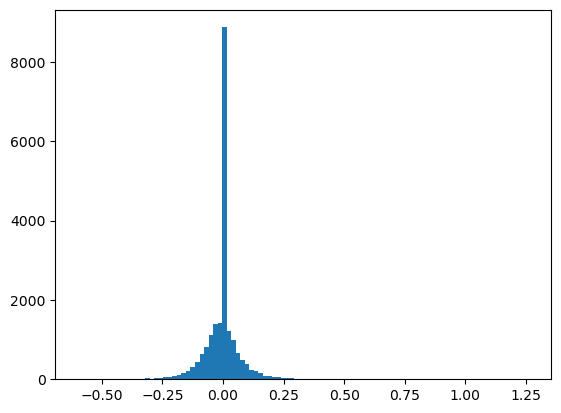

In [43]:
plt.hist(guide.median()["perturbation_score"].ravel() * map_labels.ravel(), bins=100)

(array([4192.,  421.,  546.,  838., 1454., 1848., 2125., 1954., 1719.,
        5632.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

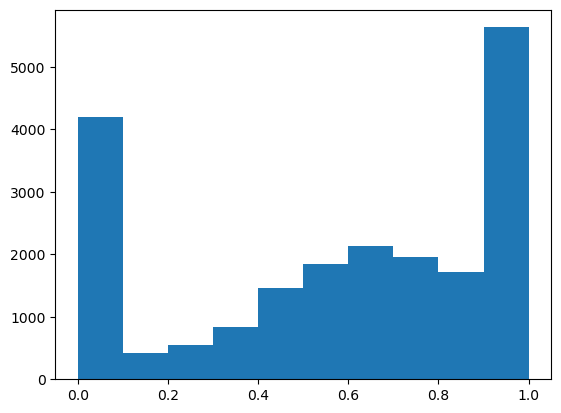

In [44]:
n_posterior_samples = 100
posterior_samples = (
    sum(classifier(args, kwargs, temperature=1) for _ in range(n_posterior_samples)) / n_posterior_samples
)
posterior_samples.mean()
plt.hist(posterior_samples.squeeze())
# plt.semilogy()

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_98914/2540703295.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


<Axes: xlabel='None', ylabel='Density'>

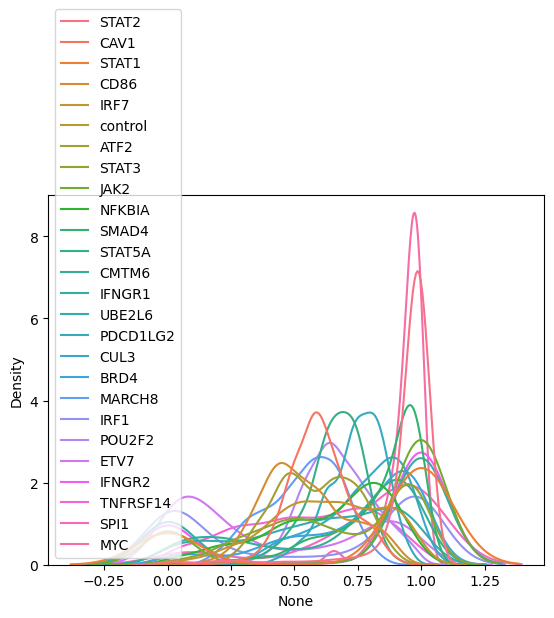

In [45]:
sns.kdeplot(
    x=posterior_samples.squeeze(),
    hue=adata_subset.obs["element"].values.squeeze(),
    common_norm=False,
    # hue_order=["IFNGR1", "IFNGR2","STAT1", "STAT2", "control"],
)

In [46]:
tolerance = 0.01
posterior_samples[(posterior_samples < (1 - tolerance)) & (posterior_samples > tolerance)]

tensor([0.9000, 0.7500, 0.3600,  ..., 0.4900, 0.5100, 0.9800])